<a href="https://colab.research.google.com/github/kamalika-m6/Generative-ai-experiments/blob/exercise3/gen_ai_exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q diffusers transformers accelerate safetensors

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU: Tesla T4


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/30 [00:00<?, ?it/s]

Image generated and saved as generated_city.png


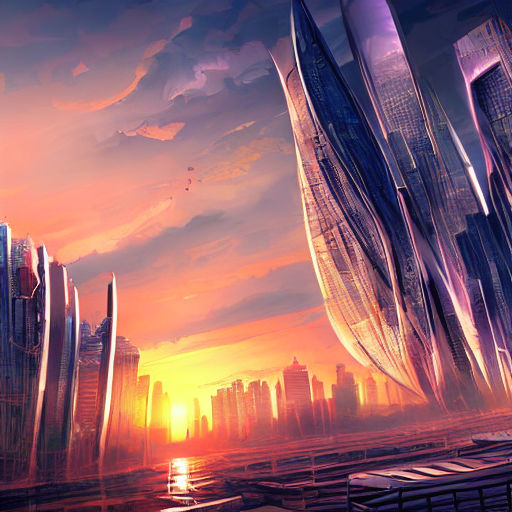

In [1]:
from diffusers import StableDiffusionPipeline
import torch

# Check GPU
if not torch.cuda.is_available():
    raise RuntimeError("GPU is not enabled. Go to Runtime > Change runtime type > T4 GPU.")

print("GPU:", torch.cuda.get_device_name(0))

# Load Stable Diffusion model
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

# Move model to GPU
pipe = pipe.to("cuda")

# Prompt
prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

# Generate image
image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

# Save image
image.save("generated_city.png")

print("Image generated and saved as generated_city.png")

# Display image in Colab
display(image)